#### Ranking quality metrics - ROC Curve, AUC, GINI

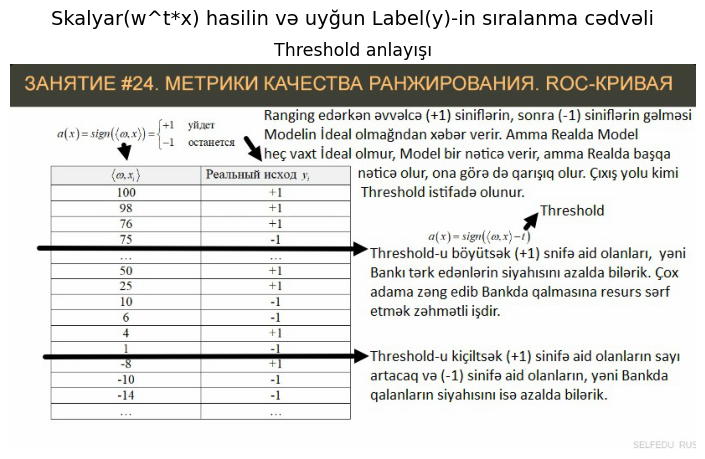

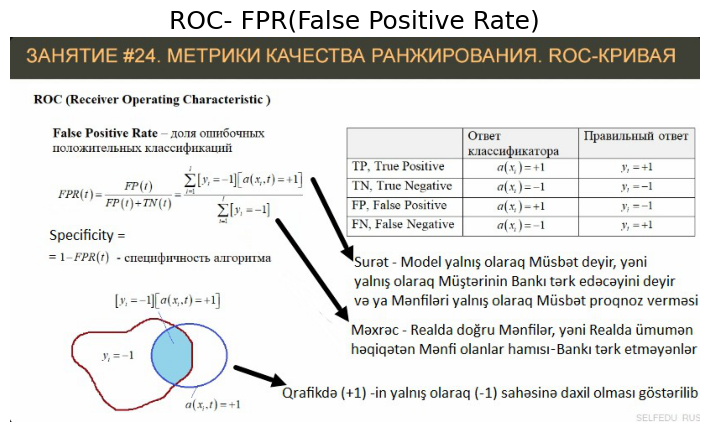

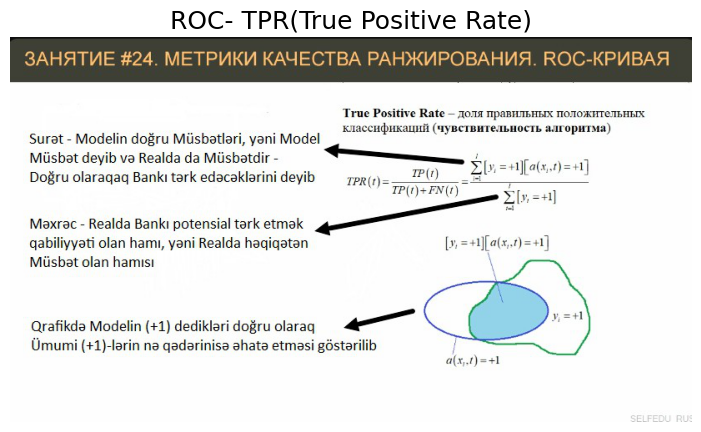

In [19]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_24_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 4):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.text(0.5, 1.1,
             "Skalyar(w^t*x) hasilin və uyğun Label(y)-in sıralanma cədvəli",
             ha='center',
             transform=plt.gca().transAxes,
             fontsize=14,
             fontweight='medium')        
        plt.title("""Threshold anlayışı""", size='12.5')
        
    elif i < 2:
        plt.title("""ROC- FPR(False Positive Rate)""", size='18')
    elif i < 3:
        plt.title("""ROC- TPR(True Positive Rate)""", size='18')         
    
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### Skalyar($\omega^t \cdot x$) hasilin və uyğun Label($y$)-in sıralanmasının (Ranging) mənası
- #### **Threshold (Hədd) Anlayışı**

> **Şəkil, təsnifat (classification) modellərində qərar vermə mexanizmini və Threshold (Hədd) anlayışını izah edir. Burada modelin çıxış qiymətləri (skalyar hasil) ilə real nəticələr arasındakı əlaqə göstərilib.**

<br>

#### **Modelin Funksiyası**
- **Şəkildə sol yuxarıda klassik xətti təsnifat funksiyası verilib:**
$$a(x) = \text{sign}(\langle w, x \rangle)$$
* **$\langle w, x \rangle$**: **Bu, çəkilər vektoru ($w$) ilə giriş datası ($x$) arasındakı skalyar hasildir. Bu əməliyyat bizə bir rəqəm (skor) verir.**
* **$\text{sign}$ (işarə funksiyası)**: **Əgər skor müsbətdirsə ($>0$), nəticə $+1$ (gedəcək), mənfidirsə ($<0$), nəticə $-1$ (qalacaq) kimi təsnif edilir.**

<br>

#### **Cədvəlin Təhlili**
- **Cədvəldə modelin hesabladığı skorlar ($\langle w, x_i \rangle$) və obyektin həqiqətdə hansı sinfə aid olduğu ($y_i$) müqayisə edilir:**

    * **Yuxarı sətirlər (Yüksək skorlar):** **Skor 100, 98, 76 olduqda, real nəticə $+1$-dir. Model burada çox dəqiqdir.**
    * **Ziddiyyətli məqamlar:** **Məsələn, skor 75 olduqda real nəticə $-1$ çıxıb, amma skor 4 olduqda real nəticə $+1$ çıxıb. Bu o deməkdir ki, modelin "sıfır" nöqtəsini qərar həddi kimi götürməsi həmişə ideal nəticə vermir.**
    * **Aşağı sətirlər (Mənfi skorlar):** **Skor $-10, -14$ olduqda nəticə $-1$-dir. Amma skor $-8$ olduqda real nəticə $+1$ çıxıb (səhv təxmin ehtimalı).**

<br>

#### **Threshold (Hədd) Anlayışı**
> **ML-də threshold — modelin çıxış ehtimalına əsasən nəticəni “pozitiv” və ya “neqativ” kimi ayıran qərar sərhədidir. Modelin verdiyi ehtimalın hansı nöqtədən sonra “bəli” qərarına çevrildiyini müəyyən edən kritik sərhəddir**

- **Şəklin sağ tərəfindəki düstur ən vacib məqamdır:**
$$a(x) = \text{sign}(\langle w, x \rangle - t)$$
- **Buradakı $t$ (threshold) parametri qərar həddidir.**


- **Niyə $t$ lazımdır?**
    > **Standart halda biz $0$-dan böyük olan hər şeyi $+1$ qəbul edirik. Lakin bəzən data elə paylanır ki, biz bu sərhədi sürüşdürməli oluruq.** 

- **Məsələn:** 

    > **Əgər bizə Recall (həssaslıq) daha vacibdirsə (heç bir $+1$ halını qaçırmaq istəmiriksə), $t$ rəqəmini kiçildərək daha çox obyekti müsbət sinfə sala bilərik.** 

    > **Əksinə, Precision (dəqiqlik) vacibdirsə, $t$-ni böyüdərək yalnız "tam əmin olduğumuz" (yüksək skorlu) halları $+1$ kimi qəbul edirik.**

<br>

#### **Xülasə**
> **Bu şəkil bizə onu göstərir ki, maşın öyrənməsi modelinin verdiyi xam skorlar ($\langle w, x \rangle$) bir növ "əminlik dərəcəsi"dir. Biz bu skorlar arasından elə bir $t$ nöqtəsi seçməliyik ki, səhvlərimiz (FP və FN) minimuma ensin.**

> **Cədvəldəki məlumatlara baxsaq, modelin ayırıcı xətti (threshold) harada çəkməsi barədə bir optimallaşdırma apardığını görürük. Bu prinsip ROC əyrisinin qurulmasının təməlini təşkil edir.**


#### **İdeal (mükəmməl) bir modelin ROC əyrisinin necə qurulduğunun riyazi olaraq izahı**

> **Təqdim etdiyiniz şəkil ideal (mükəmməl) bir modelin ROC əyrisinin necə qurulduğunu riyazi olaraq izah edir. Sizin qeyd etdiyiniz o incə məqam — yəni "TPR-in 1 olması və FPR-in də sonda 1-ə çatması" məsələsi əslində qrafikin necə hərəkət etməsi ilə bağlıdır.**

 - **Şəkldəli  ideal model məntiqini addım-addım təhlil edək:**

#### **1. Başlanğıc Nöqtəsi: Threshold ($t_1$) Çox Yüksəkdir**
- **Şəkildə sağ tərəfdə gördüyünüz düsturlar başlanğıcı göstərir. Əgər biz həddi ($t_1$) o qədər yüksək qoyuruqsa ki, model heç bir obyekti "müsbət" (1) hesab etmir:**
    * $TP = 0$ **və** $FP = 0$ **olur.**
    * **Nəticədə $TPR(t_1) = 0$ və $FPR(t_1) = 0$ olur.**
    * **Qrafikdə:** **Bu, sol aşağı küncdəki** **(0,0)** **nöqtəsidir.**
    
 
 **TPR (True Positive Rate):**
$$TPR(t_i) = \frac{TP(t_i)}{TP(t_i) + FN(t_i)} = \frac{0}{\sum_{i=1}^l [y_i = +1]} = 0$$


**FPR (False Positive Rate):**
$$FPR(t_i) = \frac{FP(t_i)}{FP(t_i) + TN(t_i)} = \frac{0}{\sum_{i=1}^l [y_i = -1]} = 0$$
    

<br>

#### **2. Threshold Azaldıqca: TPR-in 1-ə Doğru Getməsi**
- **İdeal bir modeldə bütün müsbət obyektlərin skorları ($b(x)$), mənfi obyektlərin skorlarından daha yüksəkdir. Biz threshold-u ($t$) yavaş-yavaş azaltdıqca:**

    * **Məqsəd:** **ROC əyrisini qurmaq üçün biz threshold-u (həddi) bu skorlar arasından keçirəcəyik ($t_1, t_2, \dots$)**

    $$b(x_1) \geq b(x_2) \geq b(x_3) \geq \dots \geq b(x_l)$$

    * **$TPR(t_2) = 1 / L_+$:** **Əgər biz threshold-u ($t_2$) elə qoysaq ki, yalnız bir dənə obyekt ($x_1$) müsbət sayılsın və o həqiqətən müsbətdirsə, onda True Positive Rate bütün müsbətlərin içində yalnız birini tapdığımız üçün $1/L_+$ olur.**
    * **$L_+ = \sum_{i=1}^l [y_i = +1]$:** **Bu düstur verilənlər bazasındakı **bütün real müsbət** obyektlərin cəmidir. $L_+$ sabitdir.**
    * **$FPR(t_2) = 0$:** **Həmin bu ilk obyekt həqiqi müsbətdirsə, biz hələ heç bir səhv etməmişik (heç bir mənfi obyekti müsbət saymamışıq), ona görə də False Positive Rate hələ sıfırdır.**
    * **Bu qayda ilə Threshold-u azaldqıqca obyekt sayı artır və bu düstur $TPR(t_2) = 1 / L_+$ 0-dan 1 doğru artmağa başlayır və proses aşağıdakı kimi davam edir:**

    <br>

    * **Model əvvəlcə yalnız həqiqi müsbətləri ($+1$) tutmağa başlayır.**
    * **Bu zaman $TP$ artır, amma hələ ki heç bir səhv ($FP$) etmirik.**
    * **$TPR$ sürətlə yüksəlir, $FPR$ isə hələ də **0**-da qalır.**
    * **Mükəmməl Modelin Sirri:** T**hreshold elə bir nöqtəyə çatır ki (məsələn, $t_2$), model bütün müsbət obyektləri artıq tapmış olur ($TP = L_+$).**
    * **Bu nöqtədə $TPR = 1$ və $FPR = 0$ olur. Bu, qrafikin sol yuxarı küncüdür**.
    
<br>

#### **3. Threshold Daha da Azaldıqca: FPR-in 1-ə Doğru Getməsi**
- **Bütün müsbətləri tapdıqdan sonra ($TPR=1$ olduqdan sonra) biz threshold-u azaltmağa davam etsək:**
    * **Artıq "müsbət" obyekt qalmadığı üçün model mənfi obyektləri ($-1$) də "müsbət" kimi qeyd etməyə başlayır.**
    * **Bu zaman $FP$ (yalançı həyəcanlar) artmağa başlayır.**
    * **$TPR$ artıq maksimumdadır ($1$), daha hara qalxsın? Ona görə də qrafik yuxarıdan sağa doğru üfüqi hərəkət edir.**
    * **$FPR(t_2) = 0$ düsturu 0-dan 1 doğru artmağa başlayır**
    * **Sonda threshold-u tam minimuma endirdikdə model hamıya "müsbət" deyir və $FPR$ də $1$ olur.**
    * **Qrafikdə: Bu, sağ yuxarı küncdəki (1,1) nöqtəsidir.**

<br>

#### **4. Bizim Əsas Sualımız: "FPR 1 olsa necə mükəmməl olur?"**

> **Bura çox vacibdir: Mükəmməllik (1,1) nöqtəsində deyil, (0,1) nöqtəsindədir.**

- **ROC əyrisi tək bir nöqtə deyil, threshold dəyişdikcə cızılan bir yoldur.**
* **İdeal Model: Elə bir threshold nöqtəsi var ki, orada $TPR=1$ və $FPR=0$ olur (yəni bütün xəstələri tapmısınız və heç bir sağlam adama səhvən xəstə deməmisiniz). Qrafik düz sol yuxarı küncə dəyib keçirsə, bu ideal modeldir.**
* **FPR-in 1 olması məsələsi: Threshold-u sıfıra endirsəniz, ən dahi model belə hər kəsə "müsbət" deyəcək və $FPR$ $1$ olacaq. Amma biz Modeldən istifadə edərkən həmin o "sol yuxarı küncdəki" threshold-u seçirik.**

<br>

#### **Düsturlarla Xülasə:**
- **Şəkildəki $L_+$ bütün müsbət obyektlərin sayıdır:**
$$L_+ = \sum_{i=1}^{l} [y_i = +1]$$

- **İdeal modeldə threshold azaldıqca nöqtələr belə düzülür:**
1.  $(FPR=0, TPR=0)$ -> **Heç kimi tapmadıq.**
2.  $(FPR=0, TPR=1)$ -> **Mükəmməl nöqtə!** **Bütün müsbətlər tapıldı, səhv yoxdur.**
3.  $(FPR=1, TPR=1)$ -> **Hər kəsə müsbət dedik.**

> **Mükəmməl ROC əyrisi (0,0)-dan (0,1)-ə qalxan və oradan (1,1)-ə gedən düz bucaqlı bir xəttdir. Bu zaman əyrinin altındakı sahə (AUC) tam olaraq 1.0 olur.**

> **Nəticə: $TPR=1$ olanda $FPR$-in də sonda $1$ olması modelin pis olduğunu deyil, sadəcə bizim bütün ehtimalları (threshold-ları) yoxladığımızı göstərir. Əsas odur ki, yolüstü $FPR$ hələ sıfır ikən $TPR$ artıq 1-ə çatmış olsun!**

#### **İdeal (mükəmməl) bir Modelin ROC əyrisi qurulduğu zaman Düsturlarının izahı**

#### **1. Sol yuxarıdakı düstur: Skorların Sıralanması**
$$b(x_1) \geq b(x_2) \geq b(x_3) \geq \dots \geq b(x_l)$$

- **Bu ifadə modelin bütün obyektlər üçün verdiyi xam skorları (ehtimalları və ya skalyar hasilləri) böyükdən kiçiyə doğru sıraladığımızı göstərir.**
    * $b(x_1)$ — modelin "müsbət" olma ehtimalını ən yüksək gördüyü obyektdir.
    * $b(x_l)$ — modelin "müsbət" olma ehtimalını ən aşağı gördüyü obyektdir.
* **Məqsəd:** **ROC əyrisini qurmaq üçün biz threshold-u (həddi) bu skorlar arasından keçirəcəyik ($t_1, t_2, \dots$).**


<br>

#### **2. Onun altındakı düsturlar qrupu: Addım-addım irəliləyiş**
- **Burada threshold-un (həddin) bir addım sürüşdürülməsi zamanı baş verənlər göstərilir:**

    * **$L_+ = \sum_{i=1}^l [y_i = +1]$:** **Bu düstur verilənlər bazasındakı **bütün real müsbət** obyektlərin cəmidir. $L_+$ sabitdir.**
    * **$TPR(t_2) = 1 / L_+$:** **Əgər biz threshold-u ($t_2$) elə qoysaq ki, yalnız bir dənə obyekt ($x_1$) müsbət sayılsın və o həqiqətən müsbətdirsə, onda True Positive Rate bütün müsbətlərin içində yalnız birini tapdığımız üçün $1/L_+$ olur.**
    * **$FPR(t_2) = 0$:** **Həmin bu ilk obyekt həqiqi müsbətdirsə, biz hələ heç bir səhv etməmişik (heç bir mənfi obyekti müsbət saymamışıq). Ona görə də False Positive Rate hələ sıfırdır.**

<br>

#### **3. Sağdakı iki düstur: TPR və FPR-in Ümumi Hesablanması**
- **Bu düsturlar hər hansı bir $t_i$ həddi üçün göstəricilərin necə tapıldığını ümumiləşdirir:**

- **TPR (True Positive Rate):**
$$TPR(t_i) = \frac{TP(t_i)}{TP(t_i) + FN(t_i)} = \frac{TP(t_i)}{\sum_{i=1}^l [y_i = +1]}$$
    * **Məxrəc:** **Bütün real müsbət obyektlərin sayıdır ($L_+$).**
    * **Məntiq:** **"Biz bütün həqiqi müsbət halların neçə faizini düzgün tuta bilmişik?"**

<br>

- **FPR (False Positive Rate):**
$$FPR(t_i) = \frac{FP(t_i)}{FP(t_i) + TN(t_i)} = \frac{FP(t_i)}{\sum_{i=1}^l [y_i = -1]}$$
    * **Məxrəc:** **Bütün real mənfi obyektlərin sayıdır ($L_-$).**
    * **Məntiq:** **"Biz bütün həqiqi mənfi halların (məsələn, sağlam adamların) neçə faizinə səhvən 'müsbət' (məsələn, xəstə) demişik?"**

<br>

#### **Xülasə**
- **Bu şəkil ROC əyrisinin **"addım-addım" (discrete)** necə qurulduğunu göstərir:**
    - **1. Skorları düzürük.**
    - **2. Threshold-u hər bir skorun üzərindən tək-tək keçiririk.**
    - **3. Hər dəfəsində sağdakı düsturlarla bir nöqtə $(FPR, TPR)$ hesablayırıq.**
    - **4. Bu nöqtələri birləşdirəndə ROC əyrisi yaranır.**

> **Əgər model idealdırsa, threshold azaldıqca biz əvvəlcə bütün $L_+$ sayda müsbətləri yığırıq (TPR 1-ə qalxır), sonra isə mənfiləri yığmağa başlayırıq (FPR 1-ə doğru gedir).**

#### **AUC (Area Under the Curve) və ROC (Receiver Operating Characteristic) anlayışları**

> **AUC** – “**Area Under the Curve**” deməkdir, yəni **ROC əyrisinin altında qalan sahə**. 

<br>

#### 🔹 1️⃣ **ROC nədir?**

<br> 

####  Nəyə baxır?

> **Modelin təsnifat performansını göstərmək üçün istifadə olunan bir qrafikdir.**

> **ROC** (**Receiver Operating Characteristic**) əyrisi modelin **True Positive Rate (TPR)** və **False Positive Rate (FPR)**-ni **müxtəlif threshold-larda** göstərir.

* **TPR** = **Doğru müsbətlərin nisbəti** = $ \frac{TP}{TP + FN} $ - **Gerçək müsbətlərin neçə faizi düzgün tapılıb**
* **FPR** = **Yanlış müsbətlərin nisbəti** = $ \frac{FP}{FP + TN} $ - **Gerçək mənfilərin neçə faizi səhv müsbət proqnozlanıb**

> **ROC əyrisində FPR-x oxunda, TPR-y oxunda çəkilir.**
- **X-oxu:** **FPR**
- **Y-oxu:** **TPR**
- **Hər threshold üçün bir nöqtə çəkilir → Bütün nöqtələri birləşdirəndə ROC əyrisi alınır.**

<br>

####  Məna

- **ROC əyrisi modelin ayırd etmə qabiliyyətini** göstərir.
- **Əyri nə qədər yuxarı sol küncə yaxın olsa, model bir o qədər yaxşıdır.**
- **AUC isə bu əyrinin altında qalan sahədir (0.5 təsadüfi, 1 mükəmməl).**

<br>

#### **FPR Specificity ilə düsturu**
* **Specificity (Doğru Mənfi Oranı)** belədir:

$$
\text{Specificity} = \frac{TN}{TN + FP}
$$

* **FPR (False Positive Rate)** isə **1 – Specificity** ilə də ifadə olunur:

$$
\text{FPR} = 1 - \text{Specificity} = 1 - \frac{TN}{TN + FP}
$$

> **Yəni eyni şeyin başqa formasıdır**: ya $ \frac{FP}{FP + TN} $, $1 - \frac{TN}{TN + FP}$.

<br>

#### 🔹 2️⃣ **AUC nədir?**

> **AUC sadəcə ROC əyrisinin altında qalan sahədir.**
* **Məna**: **Modelin müsbət və mənfi nümunələri ayırd etmə qabiliyyəti**.

$$
\text{AUC} = \text{ROC əyrisinin altında qalan sahə}
$$

* AUC = 0.5 → model təsadüfi proqnoz verir
* AUC = 1 → model mükəmməl proqnoz verir

<br>

####  **Ən riyazi formada (inteqral ilə)**

$$
\text{AUC} = \int_0^1 TPR \ (FPR) \ d(FPR)
$$

* Burada **TPR** = True Positive Rate = $\frac{TP}{TP+FN}$
* **FPR** = False Positive Rate = $\frac{FP}{FP+TN}$
* İnteqral FPR 0-dan 1-ə qədər götürülür.

<br>

####  **Diskret nümunələr üçün**

<br>

Əgər sən **nümunələri skora görə sıralayırsansa**:

$$
\text{AUC} = \frac{\text{Bütün düzgün sıralanmış müsbət–mənfi cütlərin sayı}}{\text{Müsbət nümunələrin sayı × Mənfi nümunələrin sayı}}
$$

Qısa:

* **Hər müsbət nümunəyə baxırsan, neçə mənfi nümunədən daha yüksək skor aldığını sayırsan.**
* **Bütün müsbət–mənfi cütləri sayıb nisbətini alırsan → AUC çıxır.**


<br>

#### **Qısa xülasə**

* AUC yüksəkdirsə → model yaxşı ayırır.
* AUC aşağıdırsa → model pis ayırır.

<br>

#### 🔹 3️⃣ **Gini coefficient**
* **AUC** (Area Under Curve) – ROC əyrisinin altında qalan sahədir, yəni modelin müsbət və mənfi nümunələri ayırma qabiliyyətini göstərir.
* **Gini coefficient** isə bənzər bir ölçüdür və düsturla hesablanır:

$$
\text{Gini} = 2 \cdot \text{AUC} - 1
$$

Qısa izah:

* AUC = 0.5 → Gini = 0 (model təsadüfi proqnoz verir)
* AUC = 1 → Gini = 1 (model mükəmməldir)

> Yəni ML-də bəzən **“2*AUC – 1”** deyəndə, **Gini indeksi** nəzərdə tutulur.

<br>

#### 🔹 4️⃣ **Niyə AUC yox, Gini?**

<br>

#### **Formula:**

$$
Gini = 2 \cdot AUC - 1
$$

<br>

#### 🔥 Niyə bunu ölçürük?

👉 Bu, modelin **ayırma qabiliyyətini (discrimination power)** ölçür

* **AUC** → **modelin 0 və 1-i nə qədər yaxşı ayırdığını göstərir**
* **Gini** → eyni şeyi **0–1 aralığında daha “təmiz” scale-də** verir

<br>

#### 💡 Məna:

* **Gini = 0** → **model random (heç nə bilmir)**
* **Gini = 1** → **ideal model**
* **Gini < 0** → **model səhv istiqamətdə işləyir**

<br>

#### 🔄 **Niyə AUC yox, Gini?**

Xüsusilə bank/credit scoring-də:

* Gini daha **standart metric** sayılır
* **interpretasiya daha rahatdır**

<br>

#### 🔥 **Nümunə:**

- **AUC = 0.5 → Gini = 0**
- **AUC = 0.8 → Gini = 0.6**
- **AUC = 1 → Gini = 1**

<br>

#### ✅ **Qısa yekun:**

**Gini = 2*AUC - 1 → modelin sinifləri nə qədər yaxşı ayırdığını ölçür**


### **ROC (Receiver Operating Characteristic) - xülasə**

> **ROC əyrisi— təsnifat modelinin müxtəlif qərar hədlərində (threshold) bütün müsbət halları tapma qabiliyyəti ($TPR$) ilə yalançı həyəcan vermə ehtimalı ($FPR$) arasındakı asılılığı və modelin ümumi ayırıcı gücünü göstərən vizual qrafikdir.** 

> **ROC (Receiver Operating Characteristic) əyrisi, təsnifat modelinin müxtəlif Threshold (qərar həddi) qiymətlərindəki performansını göstərən qrafikdir. Bu əyri iki əsas metrik arasındakı asılılığı göstərir: TPR və FPR.**

<br>

#### **1. TPR (True Positive Rate) — Həssaslıq**
- **TPR eynilə Recall (Həssaslıq) deməkdir. O, bütün real müsbət halların nə qədərinin düzgün tapıldığını göstərir.**

    $$TPR = \frac{TP}{TP + FN}$$
        
    - **Məntiqi:** **"Bütün xəstələrin neçə faizini tapdıq?"**
    - **İstənilən hal:** $TPR$-in $1.0$ **(yəni 100%) olması.**

<br>

#### **2. FPR (False Positive Rate) — Yalançı Həyəcan Səviyyəsi**
- **FPR, bütün real mənfi halların nə qədərinin səhvən "müsbət" kimi qeyd edildiyini göstərir.**

    $$FPR = \frac{FP}{FP + TN}$$
    
    <br>
    
    * **Məntiqi:** **"Bütün sağlam adamların neçə faizinə səhvən 'xəstə' dedik?"**
    * **İstənilən hal:** $FPR$-in $0$ **olması.**



<br>

#### **3. ROC Əyrisi Necə Qurulur?**
- **Şəkildə gördüyünüz o Threshold ($t$) parametri burada işə düşür. Biz $t$-ni dəyişdikcə (məsələn, 100-dən -14-ə qədər sürüşdürdükcə) hər addımda yeni bir $TPR$ və $FPR$ cütü alırıq:**

    - **1.  Hədd çox yüksəkdirsə ($t=100$):** **Model çox sərtdir, demək olar heç kimə müsbət demir. $TPR \approx 0$ və $FPR \approx 0$. (Qrafikin sol aşağı küncü).**
    - **2.  Həddi aşağı salırıq:** D**aha çox insanı "müsbət" sinfinə daxil edirik. Həm daha çox real müsbəti tapırıq ($TPR \uparrow$), həm də səhvlərimiz artır ($FPR \uparrow$).**
    - **3.  Hədd çox aşağıdırsa ($t=-100$):** **Model hamıya "müsbət" deyir. $TPR = 1$ və $FPR = 1$. (Qrafikin sağ yuxarı küncü).**

<br>

#### **Xülasə**
> **ROC əyrisi bizə modelin ayırıcı qabiliyyətini vizual olaraq göstərir. Əyri sol yuxarı küncə nə qədər yaxındırsa, model bir o qədər yaxşıdır, çünki bu, aşağı $FPR$ (az səhv) ilə yüksək $TPR$ (çox tapıntı) əldə etdiyimiz anlamına gəlir.**


### **AUC (Area Under the Curve) - xülasə**

> **A(Area Under the Curve) — ROC əyrisinin altında qalan sahənin rəqəmsal qiymətidir. Bu metrik modelin ayırıcı qabiliyyətini (müsbət və mənfi sinifləri bir-birindən nə dərəcədə yaxşı ayıra bildiyini) tək bir rəqəmlə ifadə edir.**

> **AUC (Area Under the Curve)— təsnifat modelinin müsbət və mənfi sinifləri bir-birindən ayırma qabiliyyətini bütün mümkün qərar hədləri üzrə vahid bir rəqəmlə ifadə edən və təsadüfi seçilmiş müsbət obyektin mənfi obyektdən daha yüksək skor alması ehtimalını göstərən ümumi keyfiyyət ölçüsüdür.** 

- **Maşın öyrənməsində tam adı **ROC-AUC** olaraq keçir.**

<br>

#### **1. AUC-nin Riyazi və Məntiqi Mənası**
- **AUC $0$ ilə $1$ arasında bir qiymət alır:**

    * **AUC = 1.0 (Mükəmməl Model):** **Model bütün müsbət halları mənfi hallardan tamamilə ayırır. Heç bir səhv (FP və ya FN) yoxdur.**
    * **AUC = 0.5 (Təsadüfi Seçim):** **Modelin heç bir fərqləndirmə qabiliyyəti yoxdur. Bu, sanki qəpik ataraq qərar vermək kimidir. Qrafikdə bu, diaqonal düz xətt kimi görünür.**
    * **0.7 < AUC < 0.9:** **Yaxşı və çox yaxşı model hesab olunur.**
    * **AUC < 0.5:** **Model "tərs" işləyir. Yəni müsbətlərə mənfi, mənfilərə müsbət deyir (bu halda siniflərin yerini dəyişsəniz AUC yüksələcək).**

<br>

#### **2. AUC-nin Üstünlüyü Nədir?**
- **Niyə sadəcə Accuracy (Dəqiqlik) yox, AUC-yə baxırıq?**

> **1.  Threshold-dan (Hədd) Asılı Deyil:** **Accuracy hesablamaq üçün biz bir hədd ($t$) seçməliyik (məsələn, 0.5-dən böyükdürsə $+1$ de). Amma AUC bütün mümkün hədd qiymətlərini nəzərə alaraq ümumi mənzərəni göstərir.**

> **2.  Balanssız Data (Imbalanced Data):** **Əgər əlinizdə 990 sağlam və 10 xəstə adam varsa, model hamıya "sağlam" desə Accuracy 99% olacaq (aldadıcı nəticə). Amma belə halda AUC çox aşağı çıxacaq və modelin zəif olduğunu sizə göstərəcək.**

<br>

#### **3. AUC-yə "Ehtimalsal" Baxış**
- **AUC-nin maraqlı bir statistik mənası var:**

> **Əgər siz təsadüfi bir müsbət obyekt və təsadüfi bir mənfi obyekt seçsəniz, AUC həmin müsbət obyektin model tərəfindən mənfi obyektdən daha yüksək skor alması ehtimalıdır.**

> **Nümunə: Əgər AUC = 0.85-dirsə, bu o deməkdir ki, modelin qarşısına bir xəstə və bir sağlam adam qoysaq, 85% ehtimalla model xəstə adama daha yüksək "risk skoru" verəcək.**

<br>

#### **4. Nə zaman AUC-yə baxmaq olmaz?**
> **AUC çox populyar olsa da, bəzi hallarda (məsələn, müsbət sinfin sayı həddindən artıq azdırsa — 1 milyonda 100 hal) PR-AUC (Precision-Recall AUC) metrikinə baxmaq daha doğru hesab olunur. Çünki ROC-AUC belə hallarda həddindən artıq "nikbin" (yüksək) nəticə göstərə bilər.**

### **Gini Coefficient (və ya Gini İndeksi) - xülasə**

> **Gini əmsalı— Modelin ayırıcılıq qabiliyyətini ROC əyrisi ilə təsadüfi seçim xətti arasındakı sahə əsasında ölçən və mükəmməl təsnifatla təsadüfi təxmin arasındakı fərqi 0 ilə 1 (və ya 0% - 100%) şkalasında ifadə edən nisbi effektivlik göstəricisidir.** 

> **Gini Coefficient (və ya Gini İndeksi) maşın öyrənməsində, xüsusilə də bank-maliyyə sektorunda (Credit Scoring) modelin ayırıcılıq qabiliyyətini ölçmək üçün istifadə olunan ən populyar metriklərdən biridir.**

> **Əslində bu termin iqtisadiyyatdan (gəlir bərabərsizliyini ölçmək üçün) götürülüb, lakin model qiymətləndirməsində ROC-AUC ilə birbaşa riyazi əlaqəsi var.**

<br>

#### **1. ROC Əyrisi və Gini Əlaqəsi**
> **Gini əmsalı ROC qrafikindəki "mükəmməl ayırıcılıq" ilə "təsadüfi seçim" arasındakı sahəni ifadə edir.**

- **Təsadüfi Model (Random):** **Qrafikdəki 45 dərəcəlik diaqonal xəttdir. Burada $AUC = 0.5$ və $Gini = 0$ olur.**
- **Sizin Modeliniz:** **ROC əyrisi bu diaqonaldan nə qədər yuxarıda (sol küncə yaxın) olarsa, Gini bir o qədər yüksək olar.**

- **Riyazi düsturu:**
    $$Gini = 2 \cdot AUC - 1$$

    - Məsələn:
    * **Əgər $AUC = 0.8$ olarsa: $Gini = 2 \cdot 0.8 - 1 = 0.6$ (və ya 60%)**
    * **Əgər $AUC = 0.5$ (təsadüfi) olarsa: $Gini = 2 \cdot 0.5 - 1 = 0$**

<br>

#### **2. Gini-nin Qiymətləndirilməsi**
- **Gini əmsalı 0 ilə 1 arasında dəyişir (bəzən mənfi də ola bilər, bu modelin tərsinə işlədiyini göstərir):**

    * **Gini = 1:** **Mükəmməl model. Bütün müsbət halları mənfilərdən tam ayırır.**
    * **0.60 - 0.80:** **Çox güclü model.**
    * **0.40 - 0.60:** **Yaxşı model.**
    * **0.20 - 0.40:** **Zəif model.**
    * **Gini = 0:** **Modelin heç bir faydası yoxdur (təsadüfi təxmin).**

<br>

#### **3. Niyə Gini-dən istifadə edirik?**
> **Banklar və sığorta şirkətləri çox vaxt AUC əvəzinə Gini-yə üstünlük verirlər, çünki:**
- 1.  **Gəlir bərabərsizliyi məntiqi:** **İqtisadiyyatda Gini "varlılar" və "kasıblar" arasındakı fərqi ölçdüyü kimi, maşın öyrənməsində də "yaxşı müştərilər" (ödənişi edənlər) və "pis müştərilər" (defoltu olanlar) arasındakı fərqi vizuallaşdırır.**
- 2.  **Daha həssas şkala:** **Gini 0 ilə 1 arasında dəyişdiyi üçün model fərqlərini görmək daha asandır. Məsələn, $0.75$ və $0.80$ AUC arasındakı fərq kiçik görünə bilər, amma Gini olaraq bu $0.50$ və $0.60$ deməkdir (fərq daha qabarıqdır).**

<br>

#### 4. **Lorenz Əyrisi (İqtisadi kök)**
- **Orijinal Gini əmsalı Lorenz əyrisi əsasında hesablanır. Burada:**
    * **A sahəsi:** **Bərabərlik xətti ilə Lorenz əyrisi arasındakı sahə.**
    * **B sahəsi:** **Əyrinin altındakı sahə.**
    $$Gini = \frac{A}{A + B}$$


> **Xülasə:** **Əgər bir modelin Gini əmsalı yüksəkdirsə, deməli o, yüksək riskli halları aşağı riskli hallardan çox kəskin şəkildə ayıra bilir.**


### **İqtisadiyyatda Gini əmsalı**

> **İqtisadiyyatda Gini əmsalı, bir ölkə və ya cəmiyyət daxilində gəlirlərin (və ya sərvətin) paylanmasındakı bərabərsizliyi ölçən ən mühüm statistik göstəricidir.**

> **Bu göstərici Lorenz əyrisi əsasında hesablanır və gəlir bölgüsünün nə dərəcədə ədalətli olduğunu rəqəmlərlə ifadə edir.**

#### **1. Qiymətləndirmə Şkalası**
- **Gini əmsalı 0 ilə 1 (və ya 0% - 100%) arasında dəyişir:**
    * **0 (Tam Bərabərlik):** **Hər kəsin gəliri eynidir. Ölkədəki bütün gəlir əhali arasında tam bərabər bölünüb.**
    * **1 (Tam Bərabərsizlik):** **Bütün gəlir yalnız bir nəfərin əlində cəmləşib, qalan hər kəsin gəliri sıfırdır.**

C:\Users\dell\AppData\Local\Temp\ipykernel_7904\1740637480.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_lorenz = np.trapz(cum_income, cum_population)


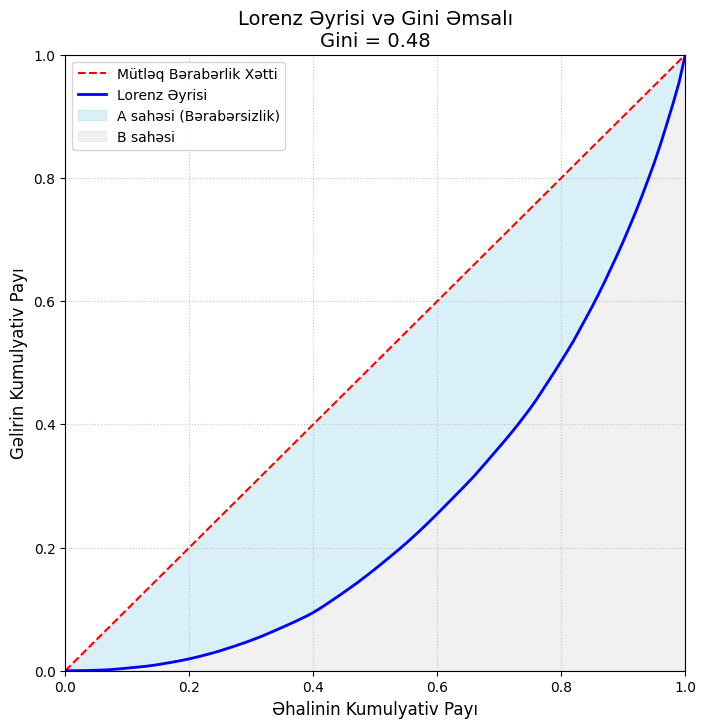

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lorenz_gini(incomes):
    # 1. Verilənləri hazırlayırıq (kiçikdən böyüyə düzürük)
    formatted_incomes = np.sort(incomes)
    n = len(formatted_incomes)
    
    # Kumulyativ əhali payı (X oxu)
    cum_population = np.arange(1, n + 1) / n
    cum_population = np.insert(cum_population, 0, 0) # 0 nöqtəsindən başlamaq üçün
    
    # Kumulyativ gəlir payı (Y oxu)
    cum_income = np.cumsum(formatted_incomes) / np.sum(formatted_incomes)
    cum_income = np.insert(cum_income, 0, 0)
    
    # 2. Gini əmsalının hesablanması (AUC məntiqi ilə)
    # Diaqonal altındakı sahə 0.5-dir. Lorenz altındakı sahəni (B) tapırıq.
    area_under_lorenz = np.trapz(cum_income, cum_population)
    gini_coef = (0.5 - area_under_lorenz) / 0.5
    
    # 3. Vizuallaşdırma
    plt.figure(figsize=(8, 8))
    
    # Mütləq bərabərlik xətti (Diaqonal)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Mütləq Bərabərlik Xətti')
    
    # Lorenz Əyrisi
    plt.plot(cum_population, cum_income, color='blue', lw=2, label='Lorenz Əyrisi')
    
    # A və B sahələrini rəngləyirik
    plt.fill_between(cum_population, cum_population, cum_income, color='skyblue', alpha=0.3, label='A sahəsi (Bərabərsizlik)')
    plt.fill_between(cum_population, cum_income, 0, color='lightgrey', alpha=0.3, label='B sahəsi')
    
    # Qrafik parametrləri
    plt.title(f'Lorenz Əyrisi və Gini Əmsalı\nGini = {gini_coef:.2f}', fontsize=14)
    plt.xlabel('Əhalinin Kumulyativ Payı', fontsize=12)
    plt.ylabel('Gəlirin Kumulyativ Payı', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    
    plt.show()

# Nümunə: 100 nəfərlik bir qrupda gəlir paylanması (bərabərsiz paylanma)
sample_incomes = np.random.exponential(scale=1000, size=100) 

plot_lorenz_gini(sample_incomes)

#### **2. Lorenz Əyrisi ilə Əlaqəsi**
- **Qrafikdə iki əsas xətt var:**
    - 1.  **Mütləq Bərabərlik Xətti:** **45 dərəcəlik diaqonal xətt.**
    - 2.  **Lorenz Əyrisi:** **Ölkədəki real gəlir paylanmasını göstərən qövs.**

- **Gini necə hesablanır?**
    - **Diaqonal xətt ilə Lorenz əyrisi arasındakı sahəni (A) ümumi üçbucağın sahəsinə (A+B) böldükdə Gini əmsalı alınır:**
    $$Gini = \frac{A}{A + B}$$

<br>

#### **3. İqtisadi Məna və Təsir**
* **Aşağı Gini (0.20 - 0.35):** **Adətən Skandinaviya ölkələrində (məsələn, Norveç, Danimarka) müşahidə olunur. Bu, gəlirlərin cəmiyyət arasında nisbətən bərabər paylandığını göstərir.**
* **Yüksək Gini (0.50 - 0.70):** **Gəlir bərabərsizliyinin çox yüksək olduğu ölkələrdə (məsələn, bəzi Afrika və Cənubi Amerika ölkələri) rast gəlinir. Bu, sosial gərginlik və yoxsulluq riskinin yüksək olması deməkdir.**

#### **Xülasə**
 - **İqtisadiyyatda Gini əmsalı bir cümlə ilə:** 
> **Ölkənin ümumi gəlirinin əhalinin faiz qrupları arasında nə dərəcədə qeyri-mütənasib bölündüyünü göstərən və Lorenz əyrisinin diaqonaldan uzaqlaşma dərəcəsi ilə ölçülən bərabərsizlik indeksidir.**

### Video Text - Russian

здравствуйте дорогие друзья я сергей балакирев и мы продолжаем знакомиться с метриками качество оценок моделей при бинарной классификации на этом занятии мы затронем весьма важный вопрос оценки качества моделей ранжирования но вначале определимся что это за класс моделей рассмотрим классический пример удержание клиентов банка сотового оператора или еще какой либо организации предположим нам поставили задачу по разработке модели который его прогнозировала по некоторым признакам x что клиент скоро покинет учреждения и если моделью дает плюс один то это прогноз того что клиенту идет а и сами нас один то останется то есть прогноз делает сот по этим признакам вектора x конечно модель делает лишь предположения уйдет клеят на самом деле или нет нам неизвестно мы можем это узнать только спустя какое то время но на всякий случай таких неуверенных клиентов было бы хорошо обзвонить и сделать съем приятное предложение чтобы держать однако ресурсы любой организации ограничены и обзванивать всех таких клиентов может оказаться очень накладно поэтому здесь лучше выделить самых неуверенных которые с наибольшей вероятностью собирается перейти в другой банк и здесь возникает вопрос как определить этих самых неуверенных для этого поступают следующим образом сортируют всех клиентов по значениям скалярного произведения

то есть наша модель формирует вот эти вот ответ плюс 1 и минус 1 на основе вы такого скалярного произведения вектора омега с вектором признаков x и если мы в таблице от ранжируем вот все эти это и образы по скалярному произведению то у нас получится такая табличка а здесь у нас реальный исход то есть вы здесь модель прогнозирует что клиент скоро уйдет выдает плюс один реальный исход это игры к этой то есть это целевые значения иногда модель совпадает с нулевым значением иногда не совпадает то есть ошибается соответствия здесь вот самые первые верхние клиенты это наиболее неуверенно и те что с наибольшей вероятностью покину учреждению ближайшем будущем а чем ниже тем все более лояльное причем мы можем по историческим данным или спустя какое-то время определить как реально себя вел тот или иной клиент ушел или остался это вот эти вот целевые значения игроки так вот при ограниченных ресурсов call-центра было бы логично увидеть в этой таблице несколько первых клиентов и именно им делать предложение от которого они не смогут отказаться и таким образом удержать их математически это можно записать следующим образом есть вот это вот т некоторый порог число по которому разделяет клиенты на нелояльных плюс 1 и лояльных -1 устанавливая например этот порог больше нуля мы будем выделять наименее лояльных клиентов с точки зрения моделей но это понятно вот смотрите из у нас порог будет увеличиваться больше нуля то есть тем самым мы будем отсекать клиентов вот по этому уровню т то есть изначально этот порог раввину и вот здесь вот порог равен нулю но если мы его будем завышать то тем самым выделяется только наименее лояльный клиент а то все что ниже порога т модель выдает здесь вот -1 то есть она считает что эти клиента лояльные то есть порог эта перемена величина и она может меняться в процессе работы вот этот алгоритм модели выделяя наименее лояльных клиентов например в зависимости от нагрузки на call центр в этом ключевая особенность алгоритмов ранжирования нам приходится разрабатывать в модель не зная конкретного порогового значения то есть она в целом для любых порогов должна давать хорошие прогнозы поведение пользователей например если при некотором пороге т упорядоченные по убыванию значений скалярного произведения будут соответствовать чередование целевых значений то есть плюс один потом -1 затем опять плюс 1 и так далее значит модель делает плохой прогноз и эффективность работы учреждения скорее всего резко снизится поэтому прежде чем применять модель на практике и ее нужно ценить и обычно это делает с помощью разработанных метр и качества алгоритмов ранжирования вообще идеальный модели ранжирования это та у которой после сортировки вот этих вот скалярных произведений целевые значения также следуют по невозрастанию т.е. сначала идут все + 1 а затем все -1 в этом случае для любого пара gt мы будем получать качественные результаты но это в идеале в реальности же существует ошибки и в этих условиях нужно понять как будет строить прогнозы модель при разных порогах д для этого поступают следующим образом используют две характеристик качества классификация модели 1 характеристикой называется фол спорить фрейд то есть доля ошибочных положительных классификации суть ее в том что она подсчитывает как часто вот этот алгоритм у а от x ошибался выдавая положительное значение то есть прогнозирую что клиент скоро уйдет с вот рецепт мы здесь в числителе используем показатель фолз позитив а мы знаем уже что фолз позитив это когда модель выдает + 1 тогда как на самом деле клиент остался бы то есть она делает ошибку и делим это все на количество образов у которых нет к -1 то есть на количество клиентов которые на самом деле лояльны в итоге вот этот показывается ли можно интерпретировать как доля ошибочных положительных классификаций а вот обратная величина определяет специфичность алгоритма ну то есть есть такой термин и я его привел чтобы вы его знали вот этот fpr можно графически изобразить вот эти вот образом мы определяем вот эту закрашенную туре по отношению ко всем образом отрицательного класса то есть водка всей вот этой вот поверхности в итоге получаем некоторое вещественно значения в диапазоне от нуля до единицы и это будет как раз вот этот fpr 2 характеристика который нам понадобится это трубу здесь фрейд то есть доля правильных положительно классификаций или по-другому чувствительность алгоритма здесь мы также смотрим сколько раз выдала модель + 1 при условии что классика ци прошла верно то есть мы здесь уже берем труп уйдите в трубу есть вот как раз моделью дает плюс 1 и метка класса тоже плюс 1 то есть метки совпадают а делим на количество положительных меток оса и графически это можно представить вот таким образом у нас есть область для положительных образов и вот здесь вот модель выдает положительное значение то есть совпадают бетти класса с тем что выдает модель и вот эту вот долю вот эту вот долю площади по отношению ко всем образом положительного класса как раз и определяет этот характеристика тпр и внимательные зрители сразу отметить что на самом деле вот этот характеристики тпр который мы только что своем виде это ничто иное как recall о котором мы говорили с вами на предыдущем занятии но когда отстроиться вот такая вот роб кривая который мы сейчас с вами будем говорить то выделяет именно две такие вот характеристики фбр и т.п. но так принято поэтому я тоже место recall здесь пишут о п р и так у нас есть две такие вот характеристики фбр и тпр который зависят вот от этого порога т потому что наша модель работает в зависимости от значения этого порогового уровня спрашивается как теперь с помощью этих характеристик оценить качество модели для задача ранжирования для этого строить следующий график сокращено он называется рок кривая здесь по одной оси откладывается fpr а по другой оси тпр и фактически в этих осях мы строим набор точек при разных пороговых значений и здесь возникает вопрос как выбирать пороговые значения выбирается они непосредст получающий выборки вот этот первый порог т1 берется таким чтобы он находился на вершине вот этого таблица то есть он был максимальным вот этот порог 5 дв следующий порог привод поэты обучающей выборки по сортированный набором данных берется вот на этом уровне уже здесь будет у нас порог т2 то есть т2 он будет отделять все вот эти вот элементы от первого элемента затем берется следующий порог т3 здесь у нас будет т4 и так далее то есть породе берутся буквально вот так вот чтобы at sea колись все вот эти вот предыдущие элемента от последующих и математически это записывается вот таким вот образом то есть у нас есть набор и вот этих вот скалярных произведений байты кстати над scaler прецедент для первого объекта то и для первой строчке tab лице это для второй и так далее очевидно когда порог равен т1 то вот эти вот характеристики у нас будут нулевые смотрите у нас вот здесь вот в числителе будет появляться 0 почему потому что модель не для одного объекта не выдаст + 1 этаж порог настолько большой что модель для всех выдает мемас 1 поэтому здесь просто получается 0 и и здесь тоже будет 0 потому что модель не для одного объекта не выдаст + 1 поэтому начальные значения при пороге т1 у нас здесь получается нулевые то есть мы всегда исходим вот из этой точке 0 далее чтобы понять как будет строиться график предположим что у нас идеальная модель то есть оно не совершает ошибок полностью совпадать с целевыми значениями тогда для следующего порога т2 мы получим некое другое значение причем вот этот показатель fpr ат-2 будет равен нулю почему он будет равен нулю потому что вот здесь в числителе у нас стоит доля не верах колокации когда модель выдает + 1 а целевое значение -1 мы сейчас предполагаю что модель идеальна она не ошибается поэтому если модель выдает + 1 то метка класса за ведом будет тоже плюс 1 и вот этих аттестаций просто не может быть поэтому у нас здесь будет 0 а вот здесь вот у нас будет единица деленная на количество положительных меток класса то есть в итоге мы получаем вот такое это распределение тпр это единица на l + l + от как раз в количество положительных меток а fpr at2 у нас будет просто ноль то есть следующий . оказывается где-то вот здесь вот у нас перебирают эти вот пороки дальше мы будем двигаться все дальше и дальше здесь вот по вертикали тоже модель у нас не ошибается и после того как мы переберем все положительные образы то вот этот показатель тпр будет равен а единица потому что здесь вот у нас будет вместо единички стоять количество положительных образов делим на количество положительных образов и получается просто единица то есть вы здесь это мой по вертикали дойдем до единицы а далее продолжаю уменьшать вот этот порог у нас будет уже увеличиваться показатель fpr и он будет идти вот следующим образом начну здесь он будет . здесь будет точкой и догнали и тоже будет доходить вот здесь вот до единиц а то есть вот здесь вот угол у нас с координатами 1 и 1 и для идеальной модели вот этот график рог кривой должен проходить вот именно так начал сюда вот эти две единицы и потом вот так вот тоже дует винница я изобразила это отдельно вот на этом рисунке то есть идеальная модель это вот этот синий график а наихудшая модель которые делает прогноз с вероятностью 0,5 то есть вероятность здесь правильного вывода + 1 или минус 1 составляет 1 2 это наихудшая модель и для такой наихудшие модели графика подроб кривой будет идти вот так по диагонали как вы уже догадались реальной модели с небольшим числом ошибок прогнозов лежат между красной и синей линиями ну как-нибудь вот так вот есть вот такой уж голубенький график это рок кривая для реальной модели но хорошо мы с вами поняли как строится это рука кривая но как теперь по ней получить числовую характеристику качество модели есть есть два распространенных подхода в первом случае просто берут площадь под этой рог кривой и она называется эта характеристика а округ то есть вокруг это вот этот площадь под рог кривой для идеальной модели она равна единица для наихудший 0,5 модель считается хорошей если вот эта вот площадь составляет примерно 0,9 и более то есть вот этот показатель вокруг он говорит о том насколько хорошо модель сортирует ранжирует объекты класса во втором случае несколько режет вычисляет вот такую то разность то есть площадь между наихудший моделью и рог кривой умноженная на 2 то есть вот это вот умноженное на 2 вот эту вот площадь такая числовая характеристика называется индекс джини или коэффициент джини но по сути дела это лишь несколько иной взгляд на ту же самую площадь повода рог кривой то есть качественно вот эти две характеристики никак не отличается между собой основным недостатком вот этих вот двух показателей является плохой учет вы и значениях несбалансированность классов например если к положительному класса то есть 100 объектов а к 30 своему миллион то площадь подарок кривой получится довольно большой выше 09 но при этом ранжирования объектов может быть очень плохим вот этот момент следует учитывать пользуясь данными характеристиками качества ранжирования

### Video Text - Azəricə



Salam, əziz dostlar! Mən Sergey Balakirev. Biz binar təsnifat zamanı modellərin qiymətləndirilmə keyfiyyət ölçüləri (metrikaları) ilə tanış olmağa davam edirik. Bu dərsimizdə reytinqləmə modellərinin keyfiyyətinin qiymətləndirilməsi kimi çox vacib bir məsələyə toxunacağıq. Lakin əvvəlcə müəyyənləşdirək ki, bu nə cür modellər sinfidir.

Klassik bir nümunəyə baxaq: bankın, mobil operatorun və ya hər hansı digər təşkilatın müştərilərini qoruyub saxlaması. Tutaq ki, qarşımıza müəyyən $x$ əlamətlərinə görə müştərinin yaxın gələcəkdə müəssisəni tərk edəcəyini proqnozlaşdıran bir model hazırlamaq tapşırığı qoyulub. Əgər model $+1$ verirsə, bu müştərinin gedəcəyi proqnozudur, $-1$ verirsə, qalacağı proqnozudur. Yəni proqnoz bu $x$ vektorunun əlamətləri əsasında verilir.

Əlbəttə, model yalnız ehtimal irəli sürür; müştərinin realda gedib-getməyəcəyini biz bilmirik. Bunu yalnız müəyyən vaxt keçdikdən sonra öyrənə bilərik. Lakin hər ehtimala qarşı, bu cür "qeyri-əmin" müştərilərə zəng edib onlara xoş bir təklif etmək yaxşı olardı ki, onları saxlaya bilək.

Ancaq hər bir təşkilatın resursları məhduddur və bütün belə müştərilərə zəng etmək çox baha başa gələ bilər. Buna görə də burada ən qeyri-əmin, başqa banka keçmək ehtimalı ən yüksək olan müştəriləri ayırmaq daha məqsədəuyğundur. Burada sual yaranır: bu ən qeyri-əmin müştəriləri necə müəyyən edək? Bunun üçün aşağıdakı kimi hərəkət edirlər: bütün müştəriləri skalyar hasilin qiymətlərinə görə sıralayırlar.

Yəni bizim modelimiz bu $+1$ və $-1$ cavablarını $\omega$ vektoru ilə $x$ əlamətlər vektorunun skalyar hasilinə əsasən formalaşdırır. Əgər biz cədvəldəki bütün obyektləri skalyar hasilə görə sıralasaq (reytinqləsək), belə bir cədvəl alınacaq: burada bizim real nəticələrimiz ($y_i$ hədəf qiymətləri) olacaq. Bəzən modelin proqnozu real nəticə ilə üst-üstə düşür, bəzən isə düşmür, yəni model səhv edir. Müvafiq olaraq, cədvəlin ən yuxarısındakı müştərilər ən qeyri-əmin və yaxın gələcəkdə müəssisəni tərk etmə ehtimalı ən yüksək olanlardır. Aşağı düşdükcə müştərilər daha sadiq (loyal) olurlar. Biz tarixi məlumatlara əsasən və ya bir müddət sonra hər bir müştərinin realda özünü necə apardığını – gedib və ya qaldığını müəyyən edə bilərik.

Çağrı mərkəzinin məhdud resursları şəraitində cədvəlin ilk bir neçə müştərisini seçmək və məhz onlara imtina edə bilməyəcəkləri təklifləri vermək məntiqli olardı və bu yolla onları saxlamaq mümkündür. Riyazi olaraq bunu belə yaza bilərik: müəyyən bir $T$ astana (threshold) qiyməti var ki, bu, müştəriləri qeyri-sadiq ($+1$) və sadiq ($-1$) olaraq ayırır. Məsələn, bu astananı sıfırdan böyük təyin etməklə biz modelin nəzərində ən az sadiq olan müştəriləri ayıracağıq. Bu aydındır: baxın, əgər astana sıfırdan yuxarı artarsa, biz müştəriləri bu $T$ səviyyəsinə görə kəsəcəyik. Başlanğıcda bu astana sıfıra bərabərdir, lakin biz onu artırdıqca yalnız ən az sadiq müştərilər seçilir. $T$ astanasından aşağıda qalan hər kəs üçün model $-1$ verir, yəni onları sadiq hesab edir.

Astananın dəyişən kəmiyyət olması və iş prosesində (məsələn, çağrı mərkəzinin yükündən asılı olaraq) dəyişə bilməsi reytinqləmə alqoritmlərinin əsas xüsusiyyətidir. Biz konkret astana dəyərini bilmədən elə model hazırlamalıyıq ki, o, istənilən astana üçün yaxşı nəticə versin. Məsələn, əgər müəyyən bir $T$ astanasında skalyar hasilin azalma sırası ilə düzülmüş siyahısında hədəf qiymətlər daim bir-birini əvəz edirsə ($+1, -1, +1, -1...$), deməli model pis proqnoz verir və müəssisənin səmərəliliyi çox güman ki, kəskin şəkildə aşağı düşəcək.

Ona görə də modeli praktikada tətbiq etməzdən əvvəl onu qiymətləndirmək lazımdır və adətən bu, reytinqləmə alqoritmləri üçün hazırlanmış keyfiyyət metrikaları ilə edilir. Ümumiyyətlə, ideal reytinqləmə modeli odur ki, skalyar hasilə görə sıralandıqdan sonra hədəf qiymətlər də azalma sırası ilə gəlsin: yəni əvvəlcə bütün $+1$-lər, sonra isə bütün $-1$-lər. Belə halda istənilən $T$ astanası üçün keyfiyyətli nəticə alarıq. Lakin bu idealdır. Real həyatda isə səhvlər mövcuddur və biz bu şəraitdə modelin müxtəlif $T$ astanalarında necə proqnozlar quracağını anlamalıyıq. Bunun üçün təsnifatın iki keyfiyyət xarakteristikasından istifadə olunur:

Birinci xarakteristika **FPR (False Positive Rate)** adlanır — yəni səhv müsbət təsnifatların payı. Mahiyyəti ondadır ki, bu alqoritm $a(x)$ modelinin müsbət qiymət verərək (müştərinin gedəcəyini proqnozlaşdıraraq) nə qədər tez-tez səhv etdiyini hesablayır. Biz burada sürətdə "False Positive" göstəricisini istifadə edirik – biz artıq bilirik ki, False Positive modelin $+1$ dediyi, lakin realda müştərinin qaldığı haldır. Bunu mənfi nişanlı ($y = -1$) obyektlərin sayına bölürük. Nəticədə bu göstərici səhv müsbət təsnifatların payı kimi interpretasiya edilə bilər. Əks kəmiyyət isə alqoritmin spesifikliyini müəyyən edir (belə bir termin var və bunu bilməyiniz üçün qeyd etdim). Bu FPR-i qrafik olaraq belə təsvir etmək olar: biz bu rənglənmiş sahəni mənfi sinfin bütün obyektlərinə (yəni bütün səthə) olan nisbətini müəyyən edirik. Nəticədə $0$ ilə $1$ diapazonunda bir həqiqi ədəd alırıq və bu, məhz FPR olacaq.

İkinci xarakteristika bizə lazım olan **TPR (True Positive Rate)** — yəni düzgün müsbət təsnifatların payı və ya başqa sözlə, alqoritmin həssaslığıdır (sensitivity). Burada biz modelin neçə dəfə $+1$ verdiyini və bu zaman təsnifatın doğru olduğunu (yəni True Positive: həm model $+1$ verir, həm də sinif nişanı $+1$-dir) yoxlayırıq və müsbət sinif nişanlarının sayına bölürük. Qrafik olaraq bunu belə təsəvvür etmək olar: müsbət obyektlər sahəmiz var və model burada müsbət qiymət verir (sinif nişanları modelin verdiyi ilə üst-üstə düşür). Bu sahənin payının müsbət sinfin bütün obyektlərinə nisbəti məhz TPR-i müəyyən edir. Diqqətli izləyicilər dərhal qeyd edəcəklər ki, əslində indicə gördüyümüz bu TPR xarakteristikası əvvəlki dərsimizdə danışdığımız **Recall** göstəricisindən başqa bir şey deyil. Lakin indi haqqında danışacağımız ROC-əyrisi qurularkən məhz FPR və TPR adlarından istifadə olunur. Belə qəbul edildiyi üçün mən də Recall əvəzinə TPR yazıram.

Beləliklə, bizim $T$ astanasından asılı olan iki xarakteristikamız var (FPR və TPR), çünki modelimiz bu astana səviyyəsindən asılı olaraq işləyir. Sual olunur: bu xarakteristikaların köməyi ilə reytinqləmə tapşırığı üçün modelin keyfiyyətini necə qiymətləndirək? Bunun üçün aşağıdakı qrafik qurulur, qısaca ona **ROC-əyrisi** deyilir. Burada bir oxda FPR, digər oxda TPR qeyd olunur və faktiki olaraq bu oxlarda biz müxtəlif astana qiymətlərində nöqtələr dəstəsi qururuq. Sual yaranır: astana qiymətləri necə seçilir? Onlar birbaşa alınan seçmədən (data) götürülür. İlk $T_1$ astanası elə götürülür ki, o, cədvəlin zirvəsində olsun, yəni maksimal olsun. Növbəti $T_2$ astanası sıralanmış məlumat dəstində birinci elementi digərlərindən ayıracaq səviyyədə götürülür. Sonra $T_3$, $T_4$ və s. Yəni astanalar elə götürülür ki, əvvəlki elementlər növbətilərdən ayrılmış olsun. Riyazi olaraq bu, skalyar hasillərin dəsti kimi yazılır.



Aydındır ki, astana $T_1$ olduqda bu xarakteristikalar sıfıra bərabər olacaq. Baxın, sürətdə $0$ yaranacaq, çünki astana o qədər böyükdür ki, model heç bir obyekt üçün $+1$ verməyəcək (hamı üçün $-1$ verir). Ona görə də başlanğıc qiymətlər $T_1$ astanasında bizdə sıfırdır, yəni həmişə $(0,0)$ nöqtəsindən başlayırıq. Sonra, qrafikin necə qurulacağını anlamaq üçün fərz edək ki, ideal modelimiz var – yəni o, səhv etmir və hədəf qiymətlərlə tam üst-üstə düşür. Onda növbəti $T_2$ astanası üçün biz başqa bir qiymət alacağıq. Bu zaman $FPR(T_2)$ sıfıra bərabər olacaq. Niyə sıfır? Çünki sürətdə modelin $+1$ dediyi, lakin hədəf qiymətin $-1$ olduğu səhv təsnifatların payı durur. Biz fərz edirik ki, model idealdır, o səhv etmir, ona görə də model $+1$ verirsə, deməli sinif nişanı mütləq $+1$-dir və belə hallar ola bilməz. TPR isə müsbət obyektlərin sayına bölünmüş bir vahid olacaq. Nəticədə biz şaquli istiqamətdə yuxarı hərəkət edirik. Bütün müsbət obyektləri keçdikdən sonra TPR vahidə bərabər olacaq. Sonra astananı azaltmağa davam etdikcə artıq FPR artmağa başlayacaq və o da sonda vahidə çatacaq. Koordinatları $(1,1)$ olan küncə gəlib çıxacağıq. İdeal model üçün ROC-əyrisi məhz belə keçməlidir: əvvəlcə yuxarı vahidə qədər, sonra sağa vahidə qədər.

Bunu ayrıca şəkildə təsvir etdim: ideal model göy qrafikdir. Ən pis model isə proqnozu $0.5$ ehtimalla verən modeldir (yəni $+1$ və ya $-1$ çıxarma ehtimalı yarı-yarıyadır). Belə ən pis model üçün ROC-əyrisi diaqonal üzrə keçəcək. Real modellər isə (az sayda səhvi olanlar) qırmızı və göy xətlərin arasında yerləşir.

Yaxşı, ROC-əyrisinin necə qurulduğunu anladıq, bəs onun vasitəsilə modelin keyfiyyətinin rəqəmsal xarakteristikasını necə alaq? İki yayılmış yanaşma var:
1. Birinci halda sadəcə ROC-əyrisinin altında qalan sahəni götürürlər və bu xarakteristika **AUC-ROC** adlanır. İdeal model üçün o $1$-ə, ən pis model üçün $0.5$-ə bərabərdir. Əgər bu sahə təxminən $0.9$ və daha çoxdursa, model yaxşı hesab olunur. AUC-ROC göstəricisi modelin sinif obyektlərini nə dərəcədə yaxşı sıraladığını (reytinqlədiyini) göstərir.
2. İkinci halda isə (bir az daha nadir hallarda) belə bir fərqi hesablayırlar: ən pis model ilə ROC-əyrisi arasındakı sahə vurulsun iki. Belə rəqəmsal xarakteristika **Cini indeksi** (və ya Cini əmsalı) adlanır. Əslində bu, eyni sahəyə bir qədər fərqli baxışdır, keyfiyyət baxımından bu iki xarakteristika bir-birindən fərqlənmir.

Bu iki göstəricinin əsas çatışmazlığı **siniflərin balanslaşdırılmamış olmasıdır**. Məsələn, müsbət sinfə 100 obyekt, mənfi sinfə isə 1 milyon obyekt aiddirsə, ROC-əyrisinin altındakı sahə kifayət qədər böyük (0.9-dan yuxarı) alına bilər, lakin eyni zamanda obyektlərin reytinqlənməsi çox pis ola bilər. Reytinqləmə keyfiyyətinin bu xarakteristikalarından istifadə edərkən bu məqamı nəzərə almaq lazımdır.

[musiqi]